In [1]:
import numpy as np
from sklearn.linear_model import QuantileRegressor
import matplotlib.pyplot as plt
import xarray as xr
import json
from joblib import Parallel, delayed
import torch
import pytorch_quantile_regression as pqr
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
# ---- Prepare test data ----
# load my data
settings_file_path = "../joint_training/v3_dpa_train_settings.json"

with open(settings_file_path, 'r') as file:
        settings = json.load(file)

# Load Z500 data
z500_test = xr.open_dataset(settings['dataset_z500_eth_test']).pseudo_pcs
z500_test_np = z500_test.values
X_test_torch = torch.from_numpy(z500_test_np.astype("float32")).to(device)
X_test_torch.shape
#z500_test_torch.shape
#X_test_torch = torch.from_numpy(X_test_np.astype("float32")).to(device)

# Temperature Test data
trefht_eth = xr.open_dataset(settings['dataset_trefht_eth_transient'])
print(trefht_eth)

# germany domain 
### Germany ###
    
# coordinates 
ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15

# cut test data
trefht_eth_ger = trefht_eth.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))
print(trefht_eth_ger)

# calculate weighted means
#weights
weights_ger_pre = np.cos(np.deg2rad(trefht_eth["lat"]))
weights_ger = weights_ger_pre / weights_ger_pre.sum()

# test_data
trefht_eth_ger_mean = trefht_eth_ger.TREFHT.weighted(weights_ger).mean(dim=("lat", "lon"))
trefht_eth_ger_mean

<xarray.Dataset> Size: 59MB
Dimensions:  (lat: 32, lon: 32, time: 14307)
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * time     (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 59MB ...
<xarray.Dataset> Size: 3MB
Dimensions:  (lat: 6, lon: 8, time: 14307)
Coordinates:
  * lat      (lat) float64 48B 48.53 49.48 50.42 51.36 52.3 53.25
  * lon      (lon) float64 64B 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
  * time     (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 3MB ...


<xarray.DataArray 'TREFHT' (time: 14307)> Size: 114kB
array([-5.78535673, -2.83797284, -1.50660743, ...,  6.41865441,
        5.3284504 ,  3.79259213], shape=(14307,))
Coordinates:
  * time     (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00

# DPA Ensemble

In [3]:
dpa_ds = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/dpa_ensemble_after_100epochs/eth_ensemble_after_100_epochs/ETH_gen_dpa_ens_100_dataset_restored.nc")
dpa_ds

<xarray.Dataset> Size: 6GB
Dimensions:          (ensemble_member: 100, time: 14307, lat: 32, lon: 32)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 0...
  * lat              (lat) float64 256B 34.4 35.34 36.28 ... 61.73 62.67 63.61
  * lon              (lon) float64 256B -11.25 -10.0 -8.75 ... 25.0 26.25 27.5
Data variables:
    TREFHT           (ensemble_member, time, lat, lon) float32 6GB ...

In [8]:
analogue_ens = xr.open_dataset("/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/analogues/analogue_ensemble_10pcs_5analogues_100analoguemembers_complete.nc")
analogue_ens.ensemble_temp.transpose("analogue_ensemble_member","time","lat","lon")

<xarray.DataArray 'ensemble_temp' (analogue_ensemble_member: 100, time: 14307,
                                   lat: 32, lon: 32)> Size: 6GB
[1465036800 values with dtype=float32]
Coordinates:
  * lat                       (lat) float64 256B 34.4 35.34 ... 62.67 63.61
  * lon                       (lon) float64 256B -11.25 -10.0 ... 26.25 27.5
  * time                      (time) object 114kB 1850-06-02 00:00:00 ... 210...
  * analogue_ensemble_member  (analogue_ensemble_member) int64 800B 0 1 ... 99

In [13]:
# coordinates 
ger_lat_min = 48
ger_lat_max = 54
ger_lon_min = 6
ger_lon_max = 15

# cut train data
trefht_dpa_trans_ger = dpa_ds.TREFHT.sel(lat=slice(ger_lat_min, ger_lat_max), lon=slice(ger_lon_min, ger_lon_max))


# calculate weighted means
#weights
weights_ger_pre = np.cos(np.deg2rad(trefht_dpa_trans_ger["lat"]))
weights_ger = weights_ger_pre / weights_ger_pre.sum()

# training data
trefht_dpa_trans_ger_mean = trefht_dpa_trans_ger.weighted(weights_ger).mean(dim=("lat", "lon"))
trefht_dpa_trans_ger_mean

<xarray.DataArray 'TREFHT' (ensemble_member: 100, time: 14307)> Size: 11MB
array([[-5.74799128, -4.92697516, -3.30843419, ...,  7.73301489,
         6.00133384,  4.41211596],
       [-7.03717519, -4.1093443 , -2.54567814, ...,  6.48018862,
         4.4997512 ,  5.30670341],
       [-6.96629547, -5.21725945, -4.14899913, ...,  6.49712177,
         4.56508114,  5.36537091],
       ...,
       [-6.22145268, -4.73881374, -3.86208636, ...,  7.65367352,
         3.65660519,  5.60613844],
       [-8.07537945, -5.4792032 , -3.11093986, ...,  5.77324166,
         5.36540742,  4.13863373],
       [-5.6010109 , -3.87305455, -3.10237168, ...,  6.22907294,
         6.48299745,  5.93782037]], shape=(100, 14307))
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 0...

(14307, 19)
Total quantiles: (19,)
Quantiles per member: (100, 19)
(19,)
(19,)
[-7.23601686e-04  1.61963926e-04 -6.29384514e-04  2.97177610e-04
  1.24439169e-04 -2.07000124e-04 -1.74692389e-04  1.93916335e-04
  1.65515405e-04  3.14338394e-04  8.04988113e-05 -2.04656664e-04
 -1.31623539e-04 -1.24983189e-04  5.32339585e-04 -1.40787347e-04
 -1.16852371e-05  4.93719158e-04  3.19313929e-03]


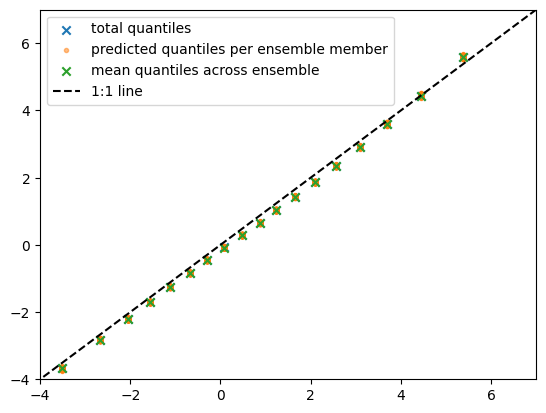

In [14]:
# quantiles of  test data
test_trefht_eth_trans_quantiles = np.quantile(trefht_eth_ger_mean, np.linspace(0.05, 0.95, 19))
test_trefht_eth_trans_quantiles.shape

# predicted quantiles per timestep (to compare with quantile regression)
dpa_trans_predicted_quantiles = np.quantile(trefht_dpa_trans_ger_mean.values.T, np.linspace(0.05, 0.95, 19), axis=1).T
print(dpa_trans_predicted_quantiles.shape)

#################################################
### quantiles of total DPA predicted ensemble ###
#################################################
dpa_trans_predicted_quantiles_total = np.quantile(trefht_dpa_trans_ger_mean.values.T, np.linspace(0.05, 0.95, 19)).T
print("Total quantiles:", dpa_trans_predicted_quantiles_total.shape)


###################################################
### dpa quantiles per predicted ensemble member ###
###################################################
dpa_trans_predicted_quantiles_per_member = np.quantile(trefht_dpa_trans_ger_mean.values.T, np.linspace(0.05, 0.95, 19), axis=0).T
print("Quantiles per member:", dpa_trans_predicted_quantiles_per_member.shape)


###########################################
### DPA quantile means of all timesteps ### does this make sense? no, right? quantiles will be different per timestep/X
###########################################
dpa_qu_mean = dpa_trans_predicted_quantiles.mean(axis=0)
print(dpa_qu_mean.shape)


############
### Plot ###
############
# total DPA quantiles
plt.scatter(test_trefht_eth_trans_quantiles, dpa_trans_predicted_quantiles_total, marker='x', label="total quantiles")

# quantiles per predicted DPA member
plt.scatter(np.repeat(test_trefht_eth_trans_quantiles,100), dpa_trans_predicted_quantiles_per_member.T.flatten(), marker='.', alpha = 0.5, label="predicted quantiles per ensemble member")

# mean of quantiles per predicted DPA member
quantiles_ensemble_mean = dpa_trans_predicted_quantiles_per_member.mean(axis=0)
print(quantiles_ensemble_mean.shape)
plt.scatter(test_trefht_eth_trans_quantiles, quantiles_ensemble_mean, marker='x', label="mean quantiles across ensemble")


plt.plot([-10, 15], [-10, 15], 'k--', label='1:1 line')

#plt.ylim(-3.8,-3.6)
#plt.xlim(-4,-3)
plt.xlim(-4,7)
plt.ylim(-4,7)

plt.legend()
print(dpa_trans_predicted_quantiles_total-quantiles_ensemble_mean)
#print()
# -> those are almost the same 

# Gradient Descent Quantile Regression

/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/baseline_quantile_regression/v3_data_quantile_regression_ger_gradient_descent_2025-11-23_19-04/metadata.json
   epoch  train_loss  val_loss
0      1    1.249216  1.206408
1      2    1.151537  1.129231
2      3    1.079925  1.062946
3      4    1.017227  1.003764
4      5    0.960373  0.949206


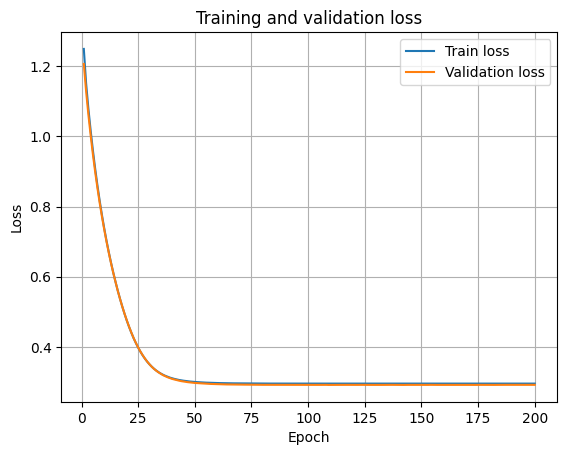

In [15]:
# Model 1
#model_path = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/baseline_quantile_regression/quantile_regression_ger_gradient_descent_v0/"

# Model 2
#model_path = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/baseline_quantile_regression/quantile_regression_ger_gradient_descent_2025-11-20_10-36/"

# Model 3 (v3 data)
model_path = "/work/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/baseline_quantile_regression/v3_data_quantile_regression_ger_gradient_descent_2025-11-23_19-04/"

# Look at loss curves
csv_path = f"{model_path}training_log.csv"

# --- 1. Load parameters from metadata.json ---

metadata_path = f"{model_path}metadata.json"  # adjust if needed
print(metadata_path)

with open(metadata_path, "r") as f:
    meta = json.load(f)

# load
df = pd.read_csv(csv_path)

# quick check
print(df.head())
# expected columns: epoch, train_loss, val_loss

plt.figure()
plt.plot(df["epoch"], df["train_loss"], label="Train loss")
plt.plot(df["epoch"], df["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
#plt.ylim(0.2, 0.4)
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()


Loaded quantiles: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]
Default delta from metadata: 1e-05
Plotting deltas: [1e-05, 0.1, 0.01, 0.5]
Quantiles used for plotting: [np.float64(0.05), np.float64(0.49999999999999994), np.float64(0.95)]


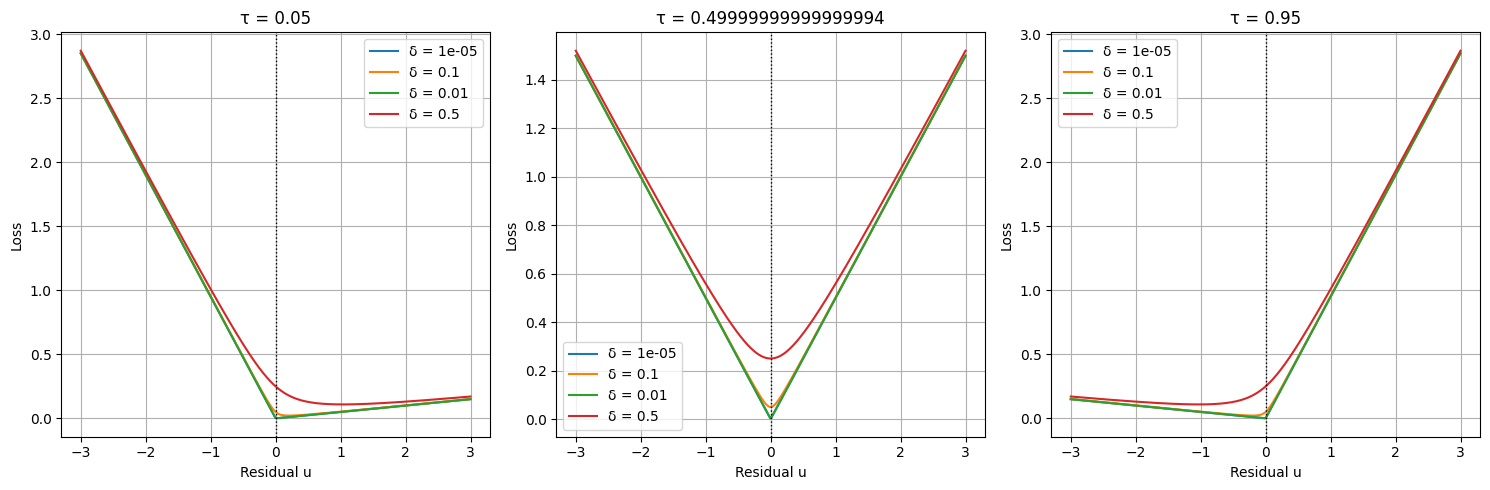

In [16]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Load quantiles & default delta from metadata.json
# ---------------------------------------------------------
quantiles = np.array(meta["quantiles"])
delta_default = float(meta["delta"])

print("Loaded quantiles:", quantiles)
print("Default delta from metadata:", delta_default)

# ---------------------------------------------------------
# 2. Choose multiple delta values to plot
# ---------------------------------------------------------

# You can override or extend with your own list:
deltas = [delta_default, 1e-1, 1e-2, 0.5]

print("Plotting deltas:", deltas)

# ---------------------------------------------------------
# 3. Define smoothed pinball loss
# ---------------------------------------------------------

def smooth_pinball_loss(u, tau, delta):
    """
    Smoothed pinball loss:
        rho_τ^δ(u) = 0.5 * ( sqrt(u^2 + δ^2) + (2τ - 1)*u )
    """
    u = np.asarray(u)
    smooth_abs = np.sqrt(u**2 + delta**2)
    return 0.5 * (smooth_abs + (2*tau - 1.0) * u)

# ---------------------------------------------------------
# 4. Select quantiles to visualize
# ---------------------------------------------------------

# Pick 3 representative quantiles (low, mid, high)
if len(quantiles) > 5:
    taus_to_plot = [
        quantiles[0],
        quantiles[len(quantiles)//2],
        quantiles[-1]
    ]
else:
    taus_to_plot = quantiles

print("Quantiles used for plotting:", taus_to_plot)

# ---------------------------------------------------------
# 5. Create grid for residuals u = y - y_pred
# ---------------------------------------------------------

u = np.linspace(-3, 3, 500)   # adjust range if needed

# ---------------------------------------------------------
# 6. Plot smoothed pinball loss for each delta
# ---------------------------------------------------------

#fig, ax = plt.subplots(figsize=(9, 6))

for delta in deltas:
    # Use τ = median (0.5) unless missing
    if 0.5 in quantiles:
        tau_mid = 0.5
    else:
        tau_mid = quantiles[len(quantiles)//2]

    loss_vals = smooth_pinball_loss(u, tau_mid, delta)
    #ax.plot(u, loss_vals, label=f"δ = {delta}")

#ax.axvline(0, color="k", linestyle=":", linewidth=1)
#ax.set_xlabel("Residual u = y - ŷ")
#ax.set_ylabel("Smoothed pinball loss")
#ax.set_title(f"Smoothed pinball loss curves for multiple δ (τ={tau_mid})")
#ax.grid(True)
#ax.legend()
#plt.tight_layout()
#plt.show()

# ---------------------------------------------------------
# 7. Optional: Multi-panel plot for different quantiles
# ---------------------------------------------------------

fig, axes = plt.subplots(1, len(taus_to_plot), figsize=(5*len(taus_to_plot), 5))

if len(taus_to_plot) == 1:
    axes = [axes]

for ax, tau in zip(axes, taus_to_plot):
    for delta in deltas:
        loss_vals = smooth_pinball_loss(u, tau, delta)
        ax.plot(u, loss_vals, label=f"δ = {delta}")

    ax.axvline(0, color="k", linestyle=":", linewidth=1)
    ax.set_title(f"τ = {tau}")
    ax.set_xlabel("Residual u")
    ax.set_ylabel("Loss")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


In [17]:


# ---- Load metadata ----
with open(f"{model_path}metadata.json", "r") as f:
    meta = json.load(f)

quantiles = meta["quantiles"]
n_features = meta["n_features"]
n_quantiles = len(quantiles)

# ---- Load checkpoint ----
ckpt_path = meta["last_checkpoint"]
checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)

# ---- Rebuild model ----
model = pqr.LinearMultiQuantileRegressor(
    n_features=n_features,
    n_quantiles=n_quantiles
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# ---- Move to GPU (optional) ----

model = model.to(device)




In [18]:
# ---- Prepare test data ----
# load my data
settings_file_path = "../joint_training/v3_dpa_train_settings.json"

with open(settings_file_path, 'r') as file:
        settings = json.load(file)

# Load Z500 data
z500_test = xr.open_dataset(settings['dataset_z500_eth_test']).pseudo_pcs
z500_test_np = z500_test.values
X_test_torch = torch.from_numpy(z500_test_np.astype("float32")).to(device)
X_test_torch.shape
#z500_test_torch.shape
#X_test_torch = torch.from_numpy(X_test_np.astype("float32")).to(device)



torch.Size([14307, 1001])

In [19]:
# ---- Predict ----
with torch.no_grad():
    preds = model(X_test_torch)   # shape (N_test, n_quantiles)
print(preds.shape)
quantile_predictions = preds.cpu().numpy()

# ---- Access individual quantiles ----
#q10 = quantile_predictions[:, 0]
#q50 = quantile_predictions[:, 1]
#q90 = quantile_predictions[:, 2]

#print("Median predictions:", q50[:10])

torch.Size([14307, 19])


# Quantile curves

(14307,)
(14307,)


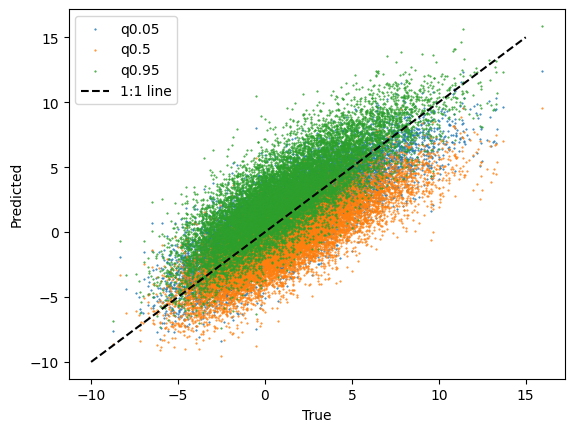

In [24]:
# true vs. predicted

plt.scatter(y_test_np, quantile_predictions[:, 8], marker='.', s=1, label = "q0.05")
plt.scatter(y_test_np, quantile_predictions[:, 0], marker='.', s=1, label = "q0.5")
plt.scatter(y_test_np, quantile_predictions[:, 18], marker='.', s=1, label = "q0.95")

plt.plot([-10, 15], [-10, 15], 'k--', label='1:1 line')
plt.xlabel("True")
plt.ylabel("Predicted")
plt.legend()
print(quantile_predictions[:, 8].shape)
print(y_test_np.shape)

(14307,)
quantiles shape: (14307, 19)


Text(0, 0.5, 'Temperature')

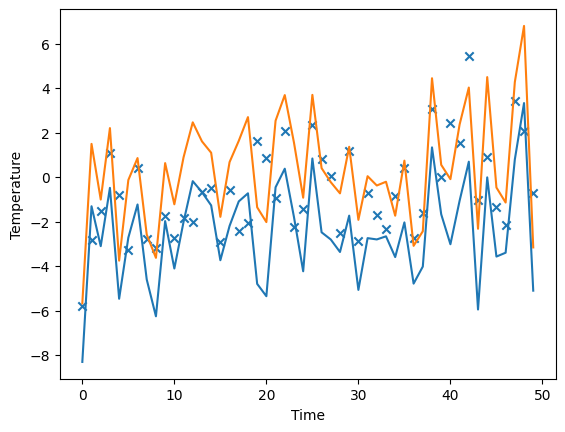

In [25]:
print(y_test_np.shape)
print("quantiles shape:", quantile_predictions.shape) # shape (sample, quantiles)
trange = 50
plt.plot(range(trange), quantile_predictions[:trange, 0], label = 'q0.05')
plt.plot(range(trange), quantile_predictions[:trange, 18], label = 'q0.95')
plt.scatter(range(trange), y_test_np[:trange], marker='x', label = 'Test data')
plt.xlabel("Time")
plt.ylabel("Temperature")

(14307,)
(14307, 19)


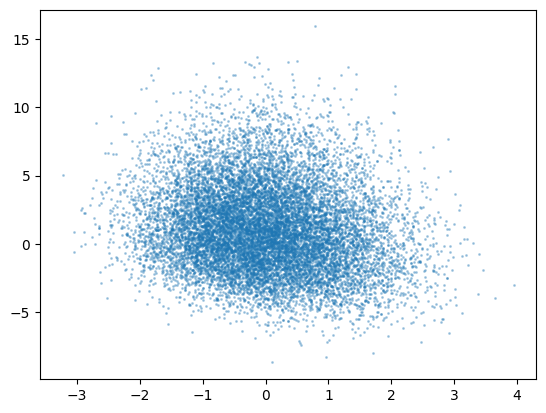

In [26]:
# choose a feature to plot against (e.g. feature 0)
feature_idx = 2
x = X_test_np[:, feature_idx]
y = y_test_np
q_hat = quantile_predictions  # (N_test, n_quantiles)

# sort by x so curves look nice
order = np.argsort(x)
x_sorted = x[order]
y_sorted = y[order]
q_sorted = q_hat[order, :]  # sort quantiles accordingly
print(y_sorted.shape)
print(q_sorted.shape)
plt.figure()
plt.scatter(x_sorted, y_sorted, s=5, alpha=0.3, label="observations", marker='.')
plt.show()


0
0.05


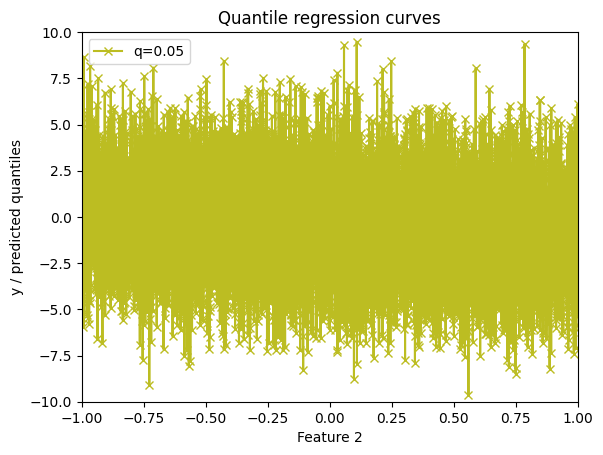

In [27]:
quantiles_sub = []
quantiles_sub.append(quantiles[0])
#quantiles_sub.append(quantiles[9])
#quantiles_sub.append(quantiles[18])
for j, tau in enumerate(quantiles_sub):
    print(j)
    print(tau)
    plt.plot(x_sorted, q_sorted[:, j], label=f"q={tau}", marker='x', color = 'tab:olive')
    plt.ylim(-10,10)
    plt.title("Tau")
    

plt.xlabel(f"Feature {feature_idx}")
plt.ylabel("y / predicted quantiles")
#plt.xlim(-1, 1)
plt.legend()
plt.title("Quantile regression curves")
plt.show()

# Calibration

In [20]:
# prepare data for validation 
X_test_np = z500_test_np
y_test_np = trefht_eth_ger_mean
quantiles = meta["quantiles"]
# quantile regression predicted quantiles
quantile_predictions = quantile_predictions

# DPA predicted quantiles
quantile_predictions_dpa = dpa_trans_predicted_quantiles

print(quantiles)

[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.39999999999999997, 0.44999999999999996, 0.49999999999999994, 0.5499999999999999, 0.6, 0.65, 0.7, 0.75, 0.7999999999999999, 0.85, 0.9, 0.95]


Qu.regression: tau=0.05, empirical coverage=0.1761
Qu.regression: tau=0.05, empirical coverage DPA=0.0965
Qu.regression: tau=0.10, empirical coverage=0.2314
Qu.regression: tau=0.10, empirical coverage DPA=0.1474
Qu.regression: tau=0.15, empirical coverage=0.2755
Qu.regression: tau=0.15, empirical coverage DPA=0.1897
Qu.regression: tau=0.20, empirical coverage=0.3139
Qu.regression: tau=0.20, empirical coverage DPA=0.2299
Qu.regression: tau=0.25, empirical coverage=0.3484
Qu.regression: tau=0.25, empirical coverage DPA=0.2681
Qu.regression: tau=0.30, empirical coverage=0.3795
Qu.regression: tau=0.30, empirical coverage DPA=0.3051
Qu.regression: tau=0.35, empirical coverage=0.4094
Qu.regression: tau=0.35, empirical coverage DPA=0.3447
Qu.regression: tau=0.40, empirical coverage=0.4387
Qu.regression: tau=0.40, empirical coverage DPA=0.3834
Qu.regression: tau=0.45, empirical coverage=0.4637
Qu.regression: tau=0.45, empirical coverage DPA=0.4213
Qu.regression: tau=0.50, empirical coverage=0.

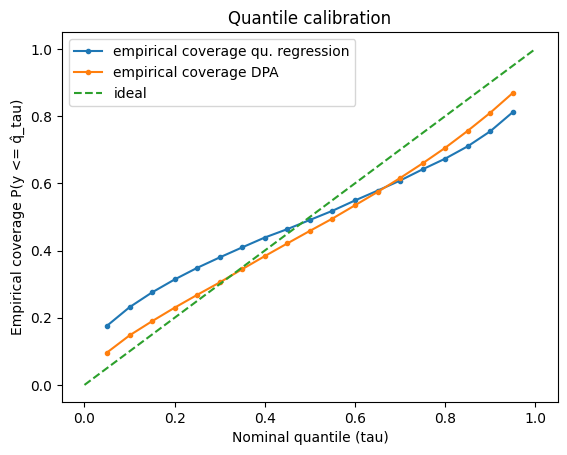

In [22]:
y = y_test_np
q_hat = quantile_predictions  # (N_test, n_quantiles)
q_hat_dpa = quantile_predictions_dpa

coverages = []
coverages_dpa = []
for j, tau in enumerate(quantiles):
    # quantile regression
    coverage = np.mean(y <= q_hat[:, j])
    coverages.append(coverage)
    print(f"Qu.regression: tau={tau:.2f}, empirical coverage={coverage:.4f}")

    # DPA
    coverage_dpa = np.mean(y <= q_hat_dpa[:, j])
    coverages_dpa.append(coverage_dpa)
    print(f"Qu.regression: tau={tau:.2f}, empirical coverage DPA={coverage_dpa:.4f}")

plt.figure()
plt.plot(quantiles, coverages, marker=".", label="empirical coverage qu. regression")
plt.plot(quantiles, coverages_dpa, marker=".", label="empirical coverage DPA")
plt.plot([0, 1], [0, 1], linestyle="--", label="ideal")
plt.xlabel("Nominal quantile (tau)")
plt.ylabel("Empirical coverage P(y <= q̂_tau)")
plt.title("Quantile calibration")
plt.legend()
plt.show()


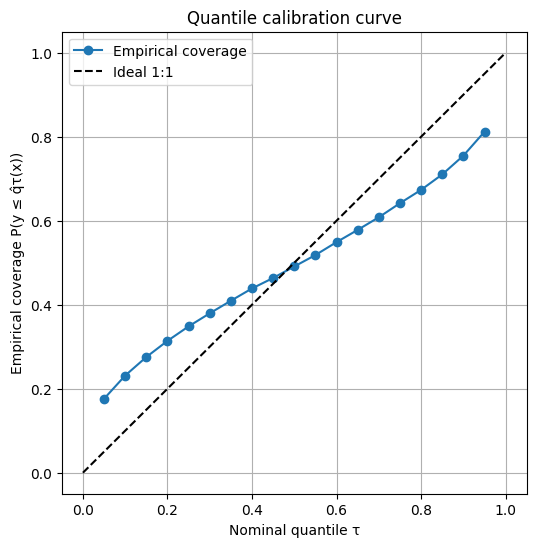

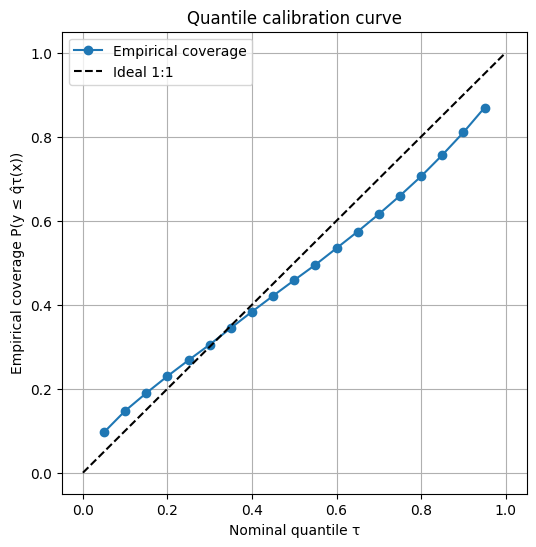

In [25]:
def compute_coverage_per_quantile(y_true, q_preds, quantiles):
    """
    y_true: (N,)
    q_preds: (N, Q)
    quantiles: (Q,)
    Returns: empirical coverages array of shape (Q,)
    """
    y_true = np.asarray(y_true).reshape(-1)
    q_preds = np.asarray(q_preds)
    quantiles = np.asarray(quantiles)

    coverages = []
    for j in range(len(quantiles)):
        tau = quantiles[j]
        q_tau = q_preds[:, j]
        cov = np.mean(y_true <= q_tau)
        coverages.append(cov)

    return np.array(coverages)


def plot_calibration_curve(y_true, q_preds, quantiles, ax=None):
    """
    Plot nominal quantile vs empirical coverage.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    quantiles = np.asarray(quantiles)
    coverages = compute_coverage_per_quantile(y_true, q_preds, quantiles)

    ax.plot(quantiles, coverages, marker="o", label="Empirical coverage")
    ax.plot([0, 1], [0, 1], "k--", label="Ideal 1:1")  # 1-1 line

    ax.set_xlabel("Nominal quantile τ")
    ax.set_ylabel("Empirical coverage P(y ≤ q̂τ(x))")
    ax.set_title("Quantile calibration curve")
    ax.grid(True)
    ax.legend()

    return ax

ax = plot_calibration_curve(y_test_np, quantile_predictions, quantiles)
ax = plot_calibration_curve(y_test_np, quantile_predictions_dpa, quantiles)

plt.show()


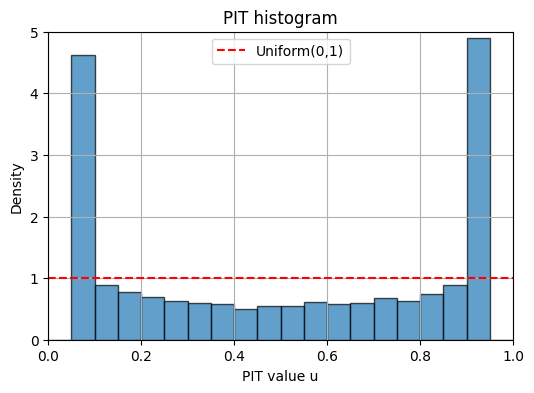

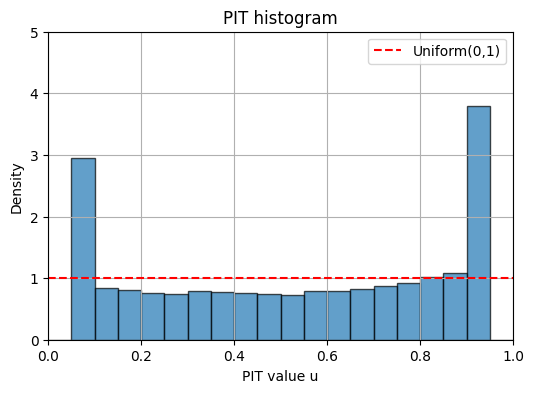

In [26]:
def compute_pit_from_quantiles(y_true, q_preds, quantiles):
    """
    Compute PIT values using piecewise linear interpolation in (τ, q̂τ(x)) space.

    y_true: (N,)
    q_preds: (N, Q) predicted quantiles for each sample
    quantiles: (Q,)
    Returns: u: (N,) PIT values in [0,1]
    """
    y_true = np.asarray(y_true).reshape(-1)
    q_preds = np.asarray(q_preds)
    taus = np.asarray(quantiles)

    N, Q = q_preds.shape
    assert Q == len(taus)

    u = np.zeros(N, dtype=float)

    for i in range(N):
        y = y_true[i]
        qs = q_preds[i, :]

        # If y below smallest predicted quantile
        if y <= qs[0]:
            u[i] = taus[0]
            continue

        # If y above largest predicted quantile
        if y >= qs[-1]:
            u[i] = taus[-1]
            continue

        # Find interval qs[k-1] <= y <= qs[k]
        idx = np.searchsorted(qs, y)
        q_low, q_high = qs[idx - 1], qs[idx]
        tau_low, tau_high = taus[idx - 1], taus[idx]

        # Linear interpolation in quantile space
        if q_high == q_low:
            # Degenerate case: quantiles equal; fall back to mid-τ
            u[i] = 0.5 * (tau_low + tau_high)
        else:
            frac = (y - q_low) / (q_high - q_low)
            u[i] = tau_low + frac * (tau_high - tau_low)

    return u

def plot_pit_histogram(u, bins=20, ax=None):
    """
    Plot PIT histogram.

    u: (N,) PIT values in [0,1]
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    ax.hist(u, bins=bins, range=(0, 1), density=True, alpha=0.7, edgecolor="black")
    # Reference uniform density line
    ax.hlines(1.0, 0, 1, colors="red", linestyles="--", label="Uniform(0,1)")

    ax.set_xlabel("PIT value u")
    ax.set_ylabel("Density")
    ax.set_title("PIT histogram")
    ax.set_xlim(0, 1)
    ax.legend()
    ax.grid(True)

    return ax

# quantile regression
u = compute_pit_from_quantiles(y_test_np, quantile_predictions, quantiles)
ax = plot_pit_histogram(u, bins=20)
plt.ylim(0,5)
plt.show()

# DPA
u = compute_pit_from_quantiles(y_test_np, quantile_predictions_dpa, quantiles)
ax = plot_pit_histogram(u, bins=20)
plt.ylim(0,5)
plt.show()

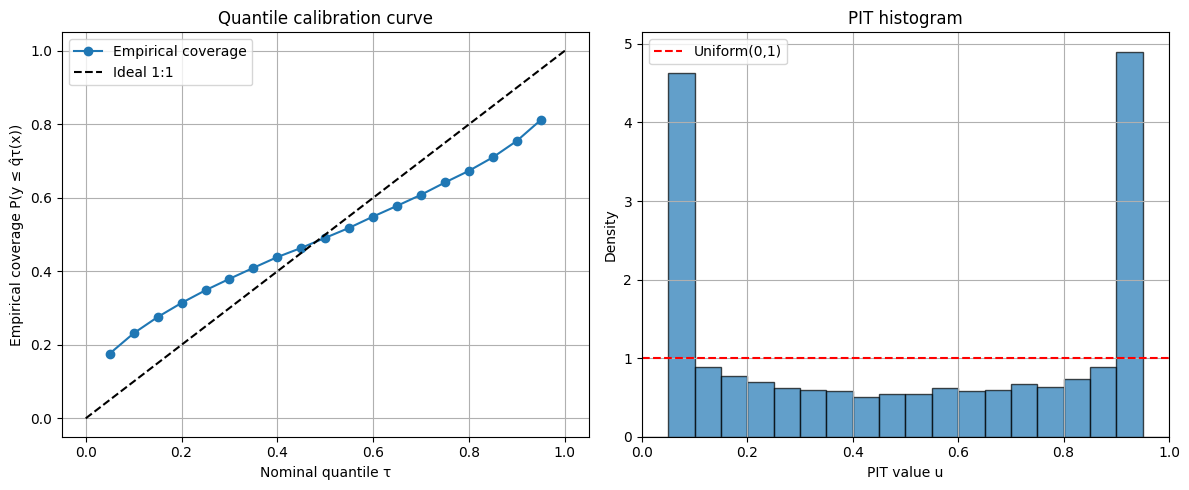

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: calibration curve
plot_calibration_curve(y_test_np, quantile_predictions, quantiles, ax=axes[0])

# Right: PIT histogram
u = compute_pit_from_quantiles(y_test_np, quantile_predictions, quantiles)
plot_pit_histogram(u, bins=20, ax=axes[1])

plt.tight_layout()
plt.show()


# add calculation of losses here?

Overall mean pinball loss: 0.5567280131306256
Overall mean pinball loss DPA: 0.32292617249026334


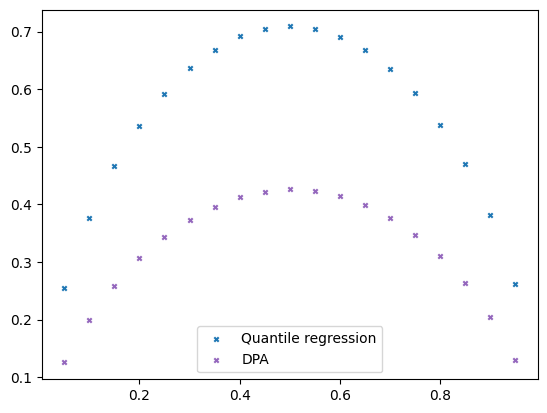

In [28]:
# Pinball/Quantile Loss

def pinball_loss_multi_np(y_true, y_pred, quantiles):
    """
    Pinball loss for multiple quantiles.

    y_true: array (N,)
    y_pred: array (N, Q)
    quantiles: list/array of Q quantile levels
    """
    y_true = np.asarray(y_true).reshape(-1, 1)    # (N,1)
    y_pred = np.asarray(y_pred)                  # (N,Q)
    taus = np.asarray(quantiles).reshape(1, -1)  # (1,Q)

    e = y_true - y_pred                          # (N,Q)

    loss = np.maximum(taus * e, (taus - 1.0) * e)  # (N,Q)

    return loss.mean()   # scalar


def pinball_loss_per_quantile_np(y_true, y_pred, quantiles):
    """
    Returns per-quantile pinball loss.

    y_true: array (N,)
    y_pred: array (N, Q)
    quantiles: list of Q quantile levels
    """
    y_true = np.asarray(y_true).reshape(-1, 1)
    y_pred = np.asarray(y_pred)
    taus = np.asarray(quantiles).reshape(1, -1)

    e = y_true - y_pred
    loss = np.maximum(taus * e, (taus - 1) * e)  # (N,Q)

    return loss.mean(axis=0)  # shape (Q,)

# Quantile regressioin
loss = pinball_loss_multi_np(y_test_np, quantile_predictions, quantiles=quantiles)
print("Overall mean pinball loss:", loss)

per_q = pinball_loss_per_quantile_np(y_test_np, quantile_predictions, quantiles=quantiles)
#for tau, val in zip(quantiles, per_q):
#    print(f"tau={tau}: loss={val:.5f}")
plt.scatter(quantiles, per_q, marker = 'x', s=10, color = "tab:blue", label = "Quantile regression")
#plt.show()

# DPA
loss_dpa = pinball_loss_multi_np(y_test_np, quantile_predictions_dpa, quantiles=quantiles)
print("Overall mean pinball loss DPA:", loss_dpa)

per_q_dpa = pinball_loss_per_quantile_np(y_test_np, quantile_predictions_dpa, quantiles=quantiles)
#for tau, val in zip(quantiles, per_q_dpa):
#    print(f"tau={tau}: loss={val:.5f}")
plt.scatter(quantiles, per_q_dpa, marker = 'x', s=10, color = "tab:purple", label = "DPA")
plt.legend()
plt.show()

# ChatGPT: --> this shape suggests underfitting

# CRPS and conditinal sharpness

In [29]:
def pinball_loss_matrix(y_true, q_preds, taus):
    """
    Compute pinball loss ρ_τ(y - q_τ(x)) for all samples and quantiles.

    y_true: (N,)
    q_preds: (N, Q)
    taus: (Q,)
    Returns: loss matrix of shape (N, Q)
    """
    y_true = np.asarray(y_true).reshape(-1, 1)   # (N,1)
    q_preds = np.asarray(q_preds)               # (N,Q)
    taus = np.asarray(taus).reshape(1, -1)      # (1,Q)

    e = y_true - q_preds                        # (N,Q)
    loss = np.maximum(taus * e, (taus - 1.0) * e)
    return loss




In [98]:

# CRPS for quantile regression (approx via quantiles)
def crps_from_quantiles(y_true, q_preds, taus):
    """
    Approximate CRPS from quantile regression outputs via:
        CRPS ≈ ∫_0^1 ρ_τ(y - q_τ) dτ  (discretized in τ)

    y_true: (N,)
    q_preds: (N, Q)
    taus: (Q,)
    Returns:
        crps_mean: scalar (mean CRPS over all samples)
        crps_per_sample: (N,) CRPS per sample
    """
    taus = np.asarray(taus)
    # ensure sorted taus
    sort_idx = np.argsort(taus)
    taus_sorted = taus[sort_idx]
    q_sorted = q_preds[:, sort_idx]

    # pinball loss matrix: (N,Q)
    loss_mat = pinball_loss_matrix(y_true, q_sorted, taus_sorted)  # (N,Q)

    # trapezoidal integration over τ axis
    # for each sample, integrate loss(τ) dτ
    # shape of loss_mat: (N,Q)
    crps_per_sample = np.trapezoid(loss_mat, x=taus_sorted, axis=1)  # (N,)

    crps_mean = crps_per_sample.mean()
    return crps_mean, crps_per_sample


# CRPS for ensemble model (exact for empirical distribution)
def crps_ensemble(y_true, ens_samples):
    """
    CRPS for an ensemble predictive distribution:

        CRPS(F, y) = E|X - y| - 0.5 E|X - X'|

    y_true: (N,)
    ens_samples: (N, K) predictive samples for each x

    Returns:
        crps_mean: scalar
        crps_per_sample: (N,)
    """
    y_true = np.asarray(y_true).reshape(-1)
    ens_samples = np.asarray(ens_samples)
    N, K = ens_samples.shape

    crps_vals = np.zeros(N, dtype=float)

    for i in range(N):
        y = y_true[i]
        s = ens_samples[i, :]              # (K,)

        # term1 = E|X - y|
        term1 = np.mean(np.abs(s - y))

        # term2 = 0.5 E|X - X'|
        # pairwise absolute differences, shape (K,K)
        diff = np.abs(s[:, None] - s[None, :])
        term2 = 0.5 * np.mean(diff)

        crps_vals[i] = term1 - term2

    crps_mean = crps_vals.mean()
    return crps_mean, crps_vals

###########################
### Quantile regression ###
###########################
qr_crps_mean, qr_crps_per_sample = crps_from_quantiles(
    y_test_np, quantile_predictions, quantiles
)
print("QR model mean CRPS:", qr_crps_mean)

###########
### DPA ###
###########
qr_crps_mean_dpa, qr_crps_per_sample_dpa = crps_from_quantiles(
    y_test_np, quantile_predictions_dpa, quantiles
)
print("DPA model mean CRPS:", qr_crps_mean_dpa)



QR model mean CRPS: 0.5159850242610641
DPA model mean CRPS: 0.30039205302942384


# Sharpness

In [31]:
def sharpness_qr(q_preds, taus, lower=0.1, upper=0.9):
    """
    Compute conditional spread for QR model:
        spread_i = q_upper(x_i) - q_lower(x_i)

    q_preds: (N, Q)
    taus: (Q,)
    lower, upper: quantile levels for spread (e.g. 0.1, 0.9)

    Returns:
        spreads: (N,)
        summary: dict with mean, median, etc.
    """
    taus = np.asarray(taus)
    q_preds = np.asarray(q_preds)

    # find nearest quantile indices
    lower_idx = np.argmin(np.abs(taus - lower))
    upper_idx = np.argmin(np.abs(taus - upper))

    q_lower = q_preds[:, lower_idx]
    q_upper = q_preds[:, upper_idx]

    spreads = q_upper - q_lower

    summary = {
        "mean_spread": spreads.mean(),
        "median_spread": np.median(spreads),
        "lower_quantile_spread": np.quantile(spreads, 0.1),
        "upper_quantile_spread": np.quantile(spreads, 0.9),
    }

    return spreads, summary

def sharpness_ensemble(ens_samples, lower=0.1, upper=0.9):
    """
    Sharpness from ensemble samples:

        spread_i = q_upper(samples_i) - q_lower(samples_i)

    ens_samples: (N, K)
    """
    ens_samples = np.asarray(ens_samples)
    lower_q = np.quantile(ens_samples, lower, axis=1)  # (N,)
    upper_q = np.quantile(ens_samples, upper, axis=1)  # (N,)

    spreads = upper_q - lower_q

    summary = {
        "mean_spread": spreads.mean(),
        "median_spread": np.median(spreads),
        "lower_quantile_spread": np.quantile(spreads, 0.1),
        "upper_quantile_spread": np.quantile(spreads, 0.9),
    }

    return spreads, summary


In [32]:

###########################
### Quantile Regression ###
###########################
qr_spreads, qr_spread_summary = sharpness_qr(
    quantile_predictions, quantiles, lower=0.1, upper=0.9
)
print("QR sharpness summary:", qr_spread_summary)

###########
### DPA ###
###########
qr_spreads_dpa, qr_spread_summary_dpa = sharpness_qr(
    quantile_predictions_dpa, quantiles, lower=0.1, upper=0.9
)
print("QR sharpness summary:", qr_spread_summary)
print("DPA QR sharpness summary:", qr_spread_summary_dpa)


# sharpness for ensemble model
#ens_spreads, ens_spread_summary = sharpness_ensemble(
#    ens_samples, lower=0.1, upper=0.9
#)
#print("Ensemble sharpness summary:", ens_spread_summary)


QR sharpness summary: {'mean_spread': np.float32(2.5570042), 'median_spread': np.float32(2.4974556), 'lower_quantile_spread': np.float32(1.786859), 'upper_quantile_spread': np.float32(3.4302003)}
QR sharpness summary: {'mean_spread': np.float32(2.5570042), 'median_spread': np.float32(2.4974556), 'lower_quantile_spread': np.float32(1.786859), 'upper_quantile_spread': np.float32(3.4302003)}
DPA QR sharpness summary: {'mean_spread': np.float64(2.015773542986938), 'median_spread': np.float64(1.976304063900578), 'lower_quantile_spread': np.float64(1.6672188014268101), 'upper_quantile_spread': np.float64(2.4236430352628466)}


QR spread summary:
  N samples      : 14307
  mean spread    : 2.557004
  median spread  : 2.497456
  10% spread     : 1.786859
  90% spread     : 3.430200
QR spread summary:
  N samples      : 14307
  mean spread    : 2.015774
  median spread  : 1.976304
  10% spread     : 1.667219
  90% spread     : 2.423643


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'QR conditional spread distribution'}, xlabel='Spread (q_upper - q_lower)', ylabel='Count'>,
 array([2.21493287, 2.05821257, 1.74391466, ..., 2.09733167, 2.38323507,
        2.11391199], shape=(14307,)),
 np.float64(2.015773542986938),
 np.float64(1.976304063900578),
 np.float64(1.6672188014268101),
 np.float64(2.4236430352628466))

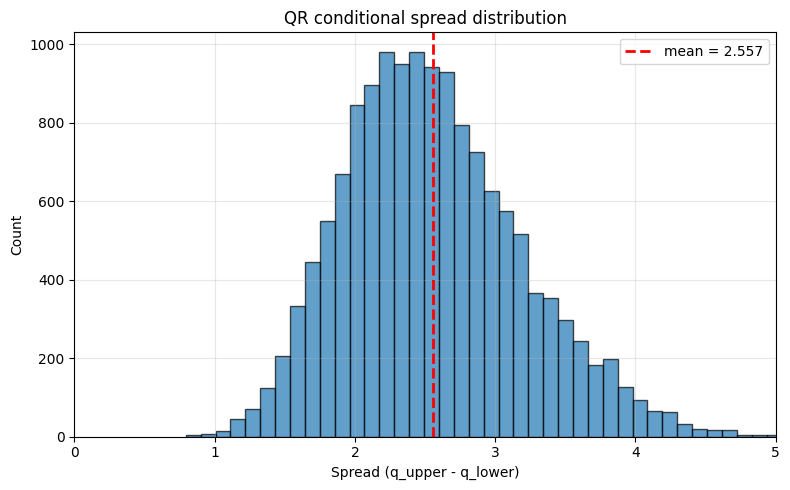

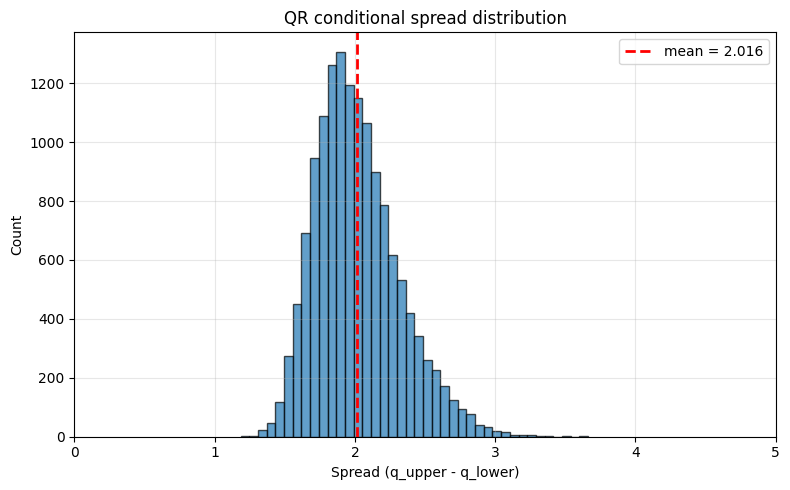

In [97]:
"""
qr_spread_plot.py

Utility for plotting the distribution of conditional spreads from a
quantile regression model (e.g. qr_spreads from sharpness_qr).
"""
def plot_qr_spreads(
    qr_spreads,
    ax=None,
    bins: int = 40,
    title: str = "QR conditional spread distribution",
    xlabel: str = "Spread (q_upper - q_lower)",
    figsize=(8, 5),
    show: bool = True,
    save_path: str | None = None,
):
    """
    Plot a histogram of QR spreads and print summary statistics.

    Parameters
    ----------
    qr_spreads : array-like, shape (N,)
        Per-sample conditional spread values, e.g. from sharpness_qr().
    bins : int, optional
        Number of histogram bins.
    title : str, optional
        Plot title.
    xlabel : str, optional
        Label for the x-axis.
    figsize : tuple, optional
        Figure size (width, height).
    show : bool, optional
        If True, call plt.show() at the end.
    save_path : str or None, optional
        If provided, save the figure to this path (e.g. "qr_spreads.png").
    """
    spreads = np.asarray(qr_spreads).reshape(-1)

    # --- summary statistics ---
    mean_spread = spreads.mean()
    median_spread = np.median(spreads)
    q10 = np.quantile(spreads, 0.10)
    q90 = np.quantile(spreads, 0.90)

    print("QR spread summary:")
    print(f"  N samples      : {spreads.size}")
    print(f"  mean spread    : {mean_spread:.6f}")
    print(f"  median spread  : {median_spread:.6f}")
    print(f"  10% spread     : {q10:.6f}")
    print(f"  90% spread     : {q90:.6f}")

    # --- histogram plot ---
    
    fig=None
    if ax is None:
        fig, ax_pre = plt.subplots(figsize=figsize)
        ax = ax_pre

    ax.hist(spreads, bins=bins, alpha=0.7, edgecolor="black")
    ax.axvline(mean_spread, color="red", linestyle="--", linewidth=2,
               label=f"mean = {mean_spread:.3f}")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlim(0,5)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150)
        print(f"Figure saved to: {save_path}")

    #if show:
        #plt.show()

    return fig, ax, spreads, mean_spread, median_spread, q10, q90


_, _, spreads, mean_spread, median_spread, q10, q90 = plot_qr_spreads(qr_spreads, bins=40)
plot_qr_spreads(qr_spreads_dpa, bins=40)
# --> shows the longer tail on the right 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: calibration curve
plot_calibration_curve(y_test_np, quantile_predictions, quantiles, ax=axes[0])

# Right: PIT histogram
u = compute_pit_from_quantiles(y_test_np, quantile_predictions, quantiles)
plot_pit_histogram(u, bins=20, ax=axes[1])

plt.tight_layout()
plt.show()


# add calculation of losses here?

In [ ]:
###############################
### Putting it all together ###
###############################

# --- CRPS comparison ---
qr_crps_mean, _ = crps_from_quantiles(y_test_np, qr_q_preds, qr_taus)
ens_crps_mean, _ = crps_ensemble(y_test_np, ens_samples)

print("Mean CRPS (QR):       ", qr_crps_mean)
print("Mean CRPS (Ensemble): ", ens_crps_mean)

# --- Sharpness comparison ---
qr_spreads, qr_spread_summary = sharpness_qr(qr_q_preds, qr_taus, 0.1, 0.9)
ens_spreads, ens_spread_summary = sharpness_ensemble(ens_samples, 0.1, 0.9)

print("QR sharpness summary:", qr_spread_summary)
print("Ensemble sharpness summary:", ens_spread_summary)


QR spread summary:
  N samples      : 14307
  mean spread    : 2.557004
  median spread  : 2.497456
  10% spread     : 1.786859
  90% spread     : 3.430200


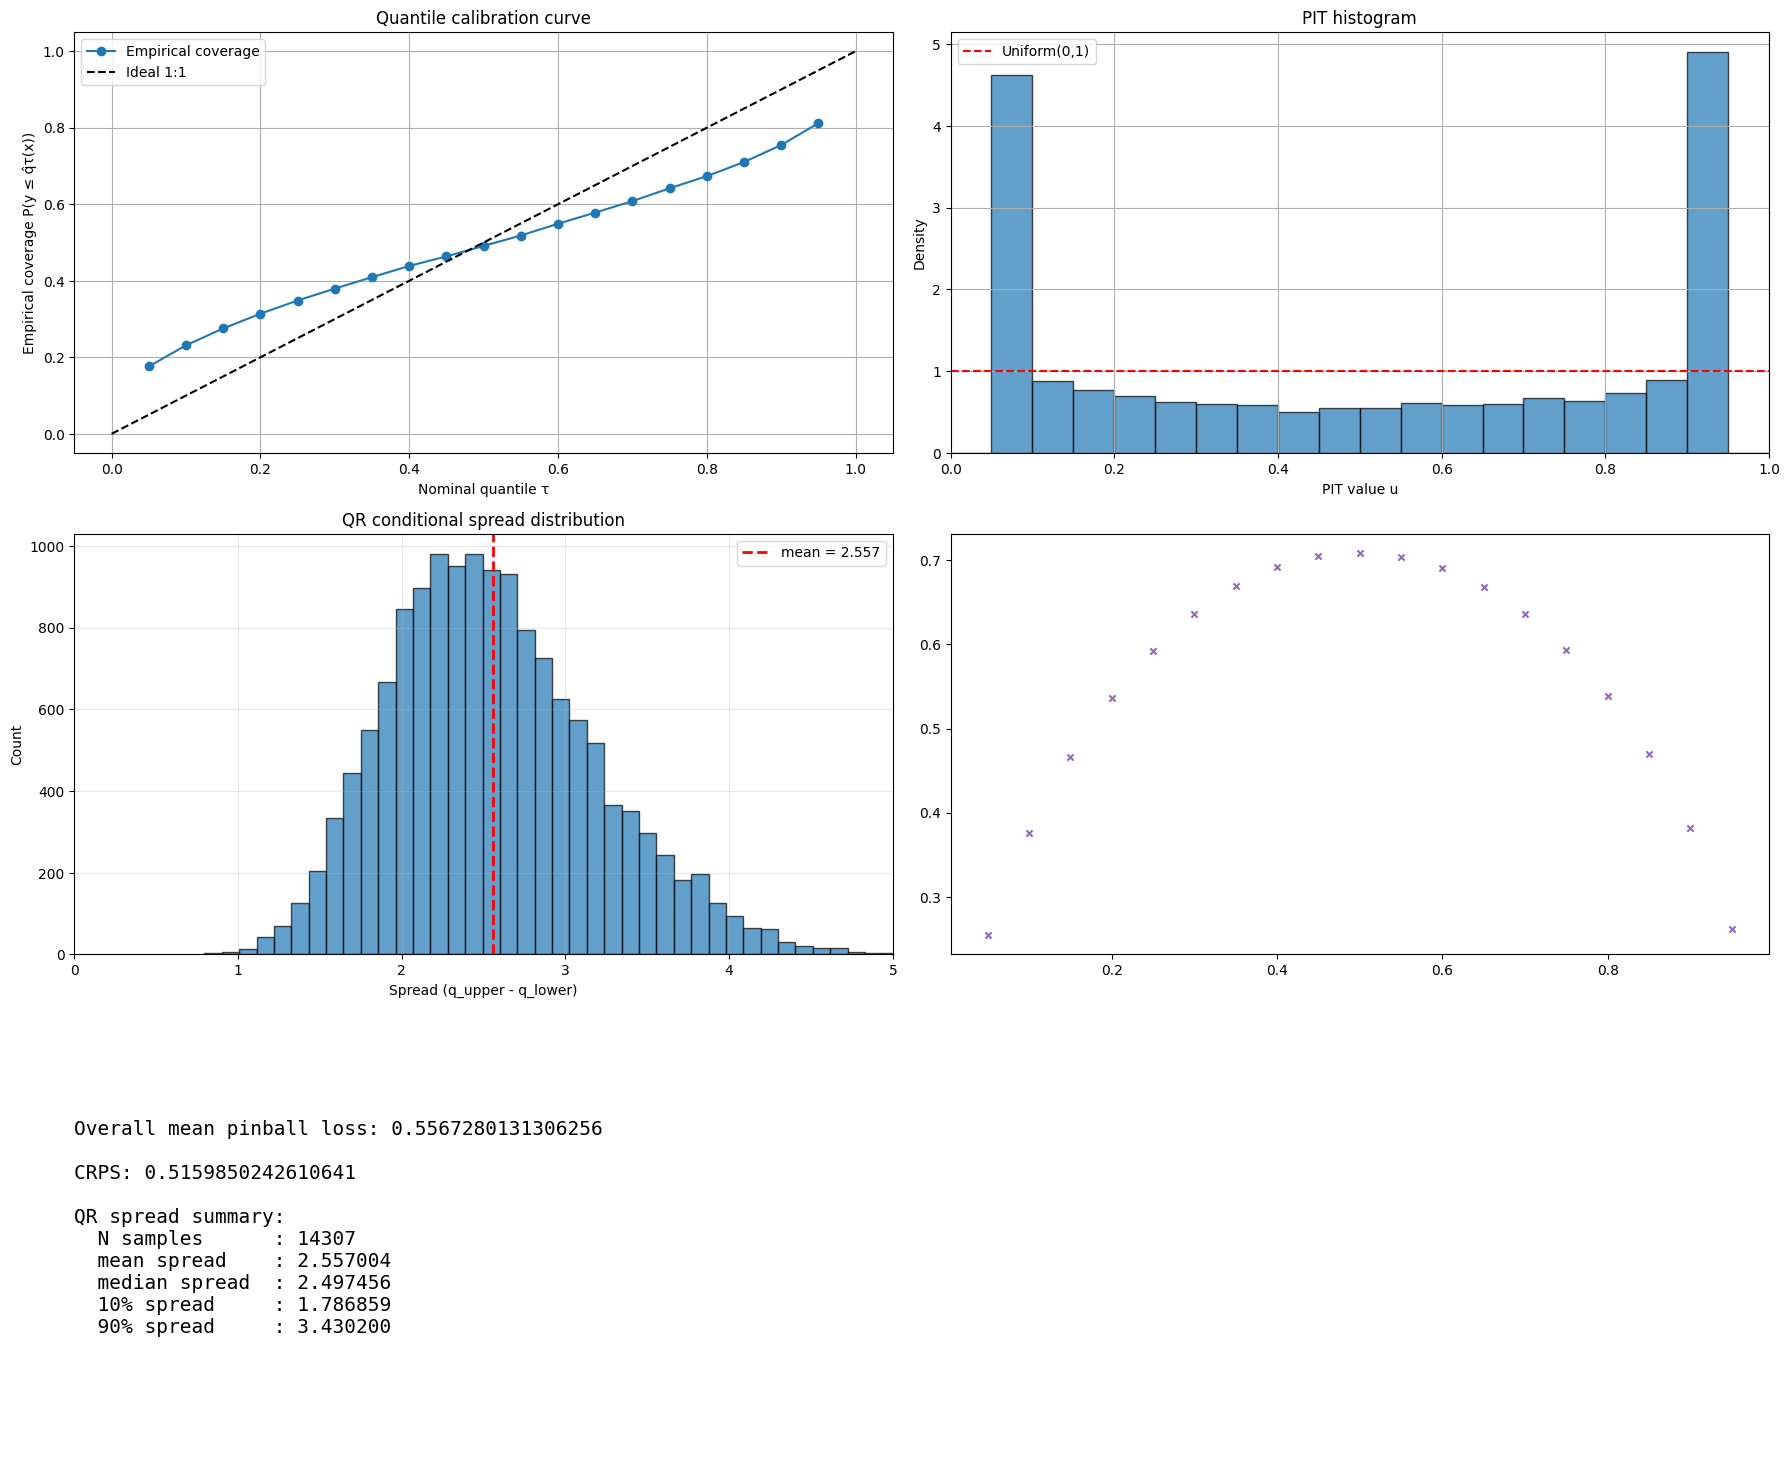

In [107]:
########################
### put all together ###
########################

fig, axes = plt.subplots(3, 2, figsize=(18, 15))

# upper Left: calibration curve
plot_calibration_curve(y_test_np, quantile_predictions, quantiles, ax=axes[0,0])

# upper Right: PIT histogram
u = compute_pit_from_quantiles(y_test_np, quantile_predictions, quantiles)
plot_pit_histogram(u, bins=20, ax=axes[0,1])

# lower left
_, _, spreads, mean_spread, median_spread, q10, q90 = plot_qr_spreads(qr_spreads, axes[1,0], bins=40)

# lower right
axes[1,1].scatter(quantiles, per_q, marker = 'x', s=20, color = "tab:purple", label = "DPA")


#plt.tight_layout()
###
# assuming you already computed these:
# spreads, mean_spread, median_spread, q10, q90

summary = (
    f"Overall mean pinball loss: {loss}\n"
    "\n"
    f"CRPS: {qr_crps_mean}\n"
    "\n"
    "QR spread summary:\n"
    f"  N samples      : {spreads.size}\n"
    f"  mean spread    : {mean_spread:.6f}\n"
    f"  median spread  : {median_spread:.6f}\n"
    f"  10% spread     : {q10:.6f}\n"
    f"  90% spread     : {q90:.6f}"
)



# Clear anything already in that axis (optional)
axes[2,0].cla()

axes[2,0].text(
    0, 0.8,              # position in axis coordinates (left, top)
    summary,
    va='top', ha='left',
    fontsize=14,
    family='monospace',    # keeps columns aligned
    transform=axes[2,0].transAxes
)

axes[2,0].set_axis_off()  # optional: hides the plot frame
axes[2,1].set_axis_off()
###
plt.show()


# 1D quantile regression with artificial data

In [2]:
# -------------------------------
# 1. Create artificial data
# -------------------------------
np.random.seed(42)
n = 300

# predictors
x1 = np.linspace(0, 10, n)
x2 = np.random.uniform(0, 5, n)
x3 = np.sin(x1) + np.random.randn(n) * 0.3

# true model + noise
true_y = 1.5 + 0.6 * x1 - 0.3 * x2 + 0.8 * x3
y = true_y + np.random.randn(n) * (0.5 + 0.2 * x1)  # heteroskedastic noise

# put everything in xarray
ds = xr.Dataset(
    {
        "y": ("sample", y),
        "x1": ("sample", x1),
        "x2": ("sample", x2),
        "x3": ("sample", x3),
        "true_y": ("sample", true_y),
    },
    coords={"sample": np.arange(n)},
)

In [4]:
ds

<xarray.Dataset> Size: 17kB
Dimensions:  (sample: 300)
Coordinates:
  * sample   (sample) int64 2kB 0 1 2 3 4 5 6 7 ... 293 294 295 296 297 298 299
Data variables:
    y        (sample) float64 2kB 0.9161 -0.6492 0.6755 ... 5.829 2.934 4.241
    x1       (sample) float64 2kB 0.0 0.03344 0.06689 ... 9.933 9.967 10.0
    x2       (sample) float64 2kB 1.873 4.754 3.66 2.993 ... 1.079 3.114 0.4267
    x3       (sample) float64 2kB 0.01367 -0.162 0.71 ... -0.758 -0.3241 -1.042
    true_y   (sample) float64 2kB 0.9491 -0.03564 1.01 ... 6.53 6.286 6.538
    y_pred   (sample) float64 2kB 3.498 3.498 3.498 3.498 ... 3.498 3.498 3.498

Predictor shape: (300, 3)
Predictand shape: (300,)
Intercept: 1.4762178856560468
Coefficients: {'x1': np.float64(0.5927750656650278), 'x2': np.float64(-0.25387579230733837), 'x3': np.float64(0.7055289343556733)}


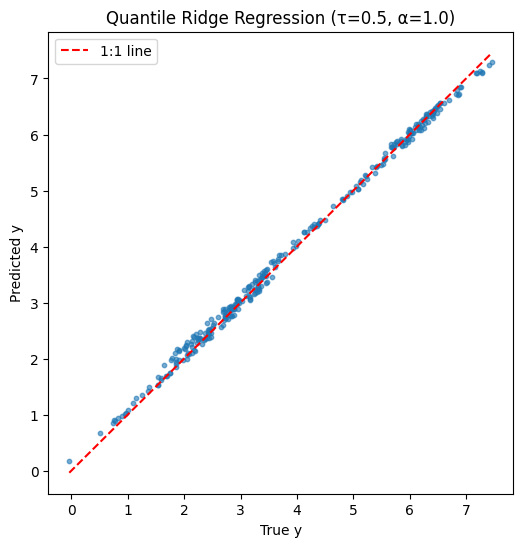

In [11]:
# -------------------------------
# 2. Prepare predictors and target
# -------------------------------
predictors = ["x1", "x2", "x3"]
X = ds[predictors].to_array().T.values  # shape (n_samples, n_features)
y = ds["y"].values

print("Predictor shape:", X.shape)
print("Predictand shape:", y.shape)

# -------------------------------
# 3. Fit Quantile Ridge Regression
# -------------------------------
model = QuantileRegressor(quantile=0.5, alpha=0.05, solver="highs").fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(predictors, model.coef_)))

# -------------------------------
# 4. Evaluate or predict
# -------------------------------
y_pred = model.predict(X)

# store back in xarray
ds["y_pred"] = (("sample",), y_pred)

# -------------------------------
# 5. Plot predicted vs true
# -------------------------------
plt.figure(figsize=(6,6))
plt.scatter(ds["true_y"], ds["y_pred"], s=10, alpha=0.6)
plt.plot([ds["true_y"].min(), ds["true_y"].max()],
         [ds["true_y"].min(), ds["true_y"].max()],
         'r--', label="1:1 line")
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("Quantile Ridge Regression (τ=0.5, α=1.0)")
plt.legend()
plt.show()


# My data for quantile regression

QR spread summary:
  N samples      : 14307
  mean spread    : 2.557004
  median spread  : 2.497456
  10% spread     : 1.786859
  90% spread     : 3.430200


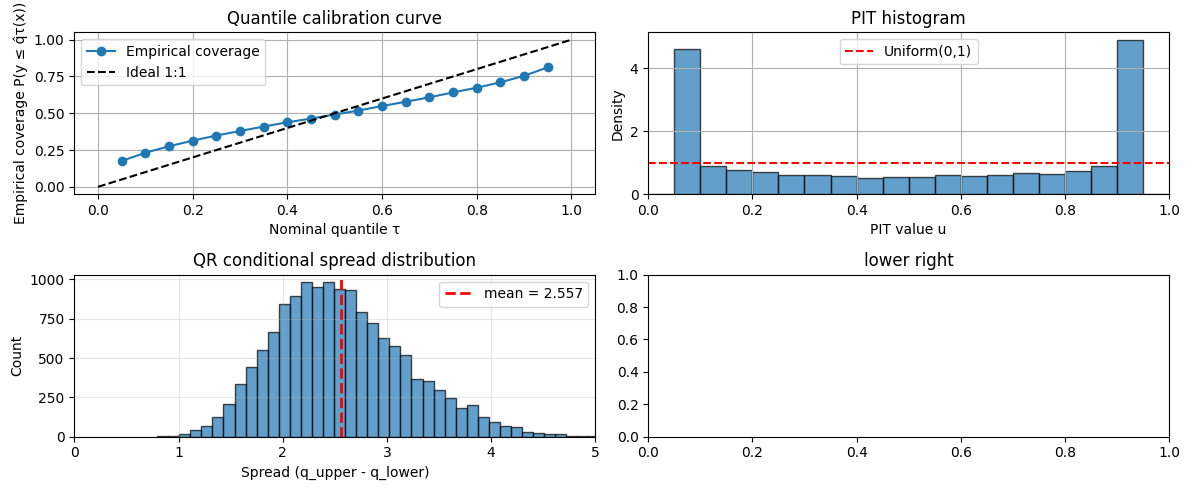

<Figure size 640x480 with 0 Axes>

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(12, 5))

axes[0,0].set_title("upper left")
axes[0,1].set_title("upper right")
axes[1,0].set_title("lower left")
axes[1,1].set_title("lower right")

# your existing code...
plot_calibration_curve(y_test_np, quantile_predictions, quantiles, ax=axes[0,0])

u = compute_pit_from_quantiles(y_test_np, quantile_predictions, quantiles)
plot_pit_histogram(u, bins=20, ax=axes[0,1])

plot_qr_spreads(qr_spreads, axes[1,0], bins=40)

axes[1,1].scatter(quantiles, per_q_dpa)#, marker='x', s=10, color="tab:purple", label="DPA")

plt.tight_layout()
plt.show()


In [53]:
print(quantiles)
print(per_q_dpa)

[0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.39999999999999997, 0.44999999999999996, 0.49999999999999994, 0.5499999999999999, 0.6, 0.65, 0.7, 0.75, 0.7999999999999999, 0.85, 0.9, 0.95]
[0.1254376  0.19995483 0.25887628 0.30603963 0.34389207 0.3736087
 0.39616934 0.41218455 0.42214817 0.42591762 0.42341557 0.41447722
 0.39901647 0.37680564 0.34752622 0.31055266 0.26425728 0.20524259
 0.13007483]


In [2]:
# load my data
settings_file_path = "../joint_training/v2_dpa_train_settings.json"

with open(settings_file_path, 'r') as file:
        settings = json.load(file)

# Load temperature data
trefht_le = xr.open_dataset(settings['dataset_trefht']).TREFHT
trefht_le

<xarray.DataArray 'TREFHT' (lat: 32, lon: 32, time: 476900)> Size: 2GB
[488345600 values with dtype=float32]
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 4MB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00

In [3]:
# Load z500 data
z500_trefht = xr.open_dataset(settings['dataset_z500']).pseudo_pcs
z500_trefht

<xarray.DataArray 'pseudo_pcs' (time: 476900, mode: 1000)> Size: 2GB
[476900000 values with dtype=float32]
Coordinates:
  * time     (time) object 4MB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
  * mode     (mode) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

Predictor shape: (500, 20)
Predictand shape: (500,)
Intercept: -0.0062419041006153255
Coefficients: {'x1': np.float64(-0.41877302586185333), 'x2': np.float64(-0.11766225828443361), 'x3': np.float64(0.18513446177234402)}


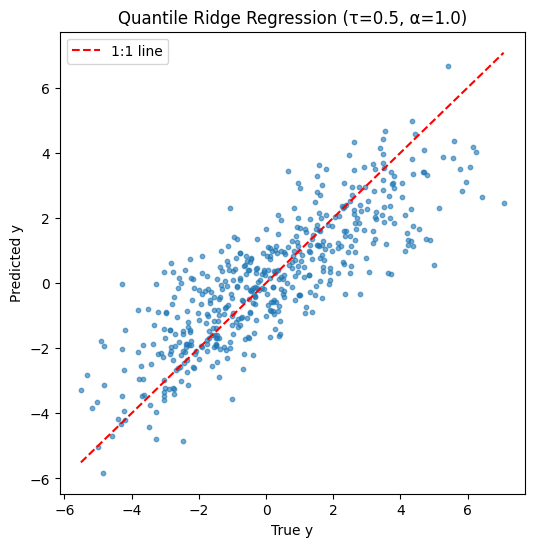

In [53]:
X = z500_trefht.values[:500,:20] # shape (n_samples, n_features)
y = trefht_le.isel(lat=10, lon=10).values[:500]
true_y = y

print("Predictor shape:", X.shape)
print("Predictand shape:", y.shape)

# -------------------------------
# 3. Fit Quantile Ridge Regression
# -------------------------------
model = QuantileRegressor(quantile=0.5, alpha=0.01, solver="highs").fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(predictors, model.coef_)))

# -------------------------------
# 4. Evaluate or predict
# -------------------------------
y_pred = model.predict(X)

# -------------------------------
# 5. Plot predicted vs true
# -------------------------------
plt.figure(figsize=(6,6))
plt.scatter(true_y, y_pred, s=10, alpha=0.6)
plt.plot([true_y.min(), true_y.max()],
         [true_y.min(), true_y.max()],
         'r--', label="1:1 line")
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("Quantile Ridge Regression (τ=0.5, α=1.0)")
plt.legend()
plt.show()

In [4]:
trefht_flat = trefht_le.stack(feature=("lat", "lon"))
trefht_flat_clean = trefht_flat.dropna(dim="feature", how="all")
trefht_flat_clean.shape



(476900, 648)

In [11]:
# Example shapes
n_samples = 100
n_features = 3
n_predictands = 648

def fit_one_target(i):
    model = QuantileRegressor(quantile=quantile, alpha=alpha, solver="highs")
    model.fit(X, Y[:, i])
    return model.intercept_, model.coef_

for i in range(n_predictands):
    print(i)
    # Artificial data (replace with your real arrays)
    X = z500_trefht.values[:n_samples, :n_features] #np.random.randn(n_samples, n_features)
    Y = trefht_flat_clean.values[:n_samples, i]#np.random.randn(n_samples, n_predictands)

    # -------------------------------
    # 3. Fit Quantile Ridge Regression
    # -------------------------------
    model = QuantileRegressor(quantile=0.5, alpha=0.05, solver="highs").fit(X, Y.T)
    
    print("Intercept:", model.intercept_)
    #print("Coefficients:", dict(zip(predictors, model.coef_)))
    
    # -------------------------------
    # 4. Evaluate or predict
    # -------------------------------
    y_pred = model.predict(X)
    
    

0
Intercept: 0.0024901948019901525
1
Intercept: 0.00920134089277935
2
Intercept: -0.3070193737363324
3
Intercept: -0.28561412680850273
4
Intercept: -0.23928733876683467
5
Intercept: 0.07147632252983897
6
Intercept: 0.17386904363811428
7
Intercept: 0.20971362870972513
8
Intercept: 0.2724613652893161
9
Intercept: -0.17164540248292132
10
Intercept: -0.15373321933903092
11
Intercept: -0.31247878535042717
12
Intercept: -0.31845655229677006
13
Intercept: -0.2885905137858182
14
Intercept: 0.008108384387404396
15
Intercept: 0.013569341500807052
16
Intercept: -0.045275872702718725
17
Intercept: -0.041546959453948984
18
Intercept: -0.05131690988886026
19
Intercept: -0.04160806949759066
20
Intercept: 0.12417571243490358
21
Intercept: 0.3711737769440518
22
Intercept: 0.3571472676050839
23
Intercept: 0.1677180363159006
24
Intercept: 0.031162568046373986
25
Intercept: -0.08863930541111986
26
Intercept: -0.23784368172854398
27
Intercept: -0.43795221870702683
28
Intercept: -0.146789681846185
29
Interc

KeyboardInterrupt: 

In [65]:
print("Predictor shape:", X.shape)
    print("Predictands shape:", Y.shape)
    
# -------------------------------
# 1. Fit one Quantile Ridge model per predictand
# -------------------------------
quantile = 0.5
alpha = 0.01



results = Parallel(n_jobs=-1, verbose=5)(
    delayed(fit_one_target)(i) for i in range(n_predictands)
)

intercepts, coefs = zip(*results)
intercepts = np.array(intercepts)
coefs = np.vstack(coefs)  # shape (n_predictands, n_features)

print("Fitted coefficients:", coefs.shape)

# -------------------------------
# 2. Predict all predictands
# -------------------------------
Y_pred = X @ coefs.T + intercepts  # broadcasted addition
print("Prediction shape:", Y_pred.shape)  # (n_samples, n_predictands)

# -------------------------------
# 3. Example: plot one predictand
# -------------------------------
i = 0  # e.g., predictand index 0
plt.figure(figsize=(6,6))
plt.scatter(Y[:, i], Y_pred[:, i], s=10, alpha=0.6)
plt.plot([Y[:, i].min(), Y[:, i].max()],
         [Y[:, i].min(), Y[:, i].max()],
         'r--', label="1:1 line")
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title(f"Quantile Ridge Regression (τ={quantile}, α={alpha}) — Predictand {i}")
plt.legend()
plt.show()


(500, 100)

# Evaluate regression results

In [2]:
# open results
import xarray as xr
ds = xr.open_dataset('results/quantile_regression_results.nc')
ds

<xarray.Dataset> Size: 30MB
Dimensions:       (predictand: 648, predictor: 1000, sample: 4769)
Coordinates:
  * sample        (sample) int64 38kB 0 1 2 3 4 5 ... 4764 4765 4766 4767 4768
  * predictand    (predictand) int64 5kB 0 1 2 3 4 5 ... 642 643 644 645 646 647
  * predictor     (predictor) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables:
    coefficients  (predictand, predictor) float64 5MB ...
    intercepts    (predictand) float64 5kB ...
    predictions   (sample, predictand) float64 25MB ...
Attributes:
    model:          QuantileRegressor
    quantile:       0.5
    alpha:          0.01
    n_samples:      4769
    n_predictors:   1000
    n_predictands:  648
    description:    Quantile ridge regression results for TREFHT predicted fr...